In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
import pandas as pd

df = pd.read_csv(r"C:\GIT\customer-shopping-behaviour-analysis\Dataset\shopping_behavior.csv")

df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Yes,31,PayPal,Annually


In [5]:
df.shape

(3900, 16)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Discount Applied        3900 non-null   object 
 13  Previous Purchases      3900 non-null   int64  
 14  Payment Method          3900 non-null   

In [7]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [10]:
df.isnull().sum()


Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Discount Applied          0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
missing_age = df["Age"].isnull().sum()
print(f"Number of missing values in 'Age' column: {missing_age}")

Number of missing values in 'Age' column: 0


Data Understanding & Feature Engineering

Create Age Groups

In [14]:
# Define the age boundaries for each age group
bins = [0,20,30,40,50,60,100]

# Define the labels for each age group
labels = [ 'Under 20', '20-30', '31-40', '41-50', '51-60', '60+' ]

# Create the new Categorical column
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)


# Display the count of records in each age group
df['Age_Group'].value_counts().sort_index()


Age_Group
Under 20    212
20-30       737
31-40       725
41-50       750
51-60       753
60+         723
Name: count, dtype: int64

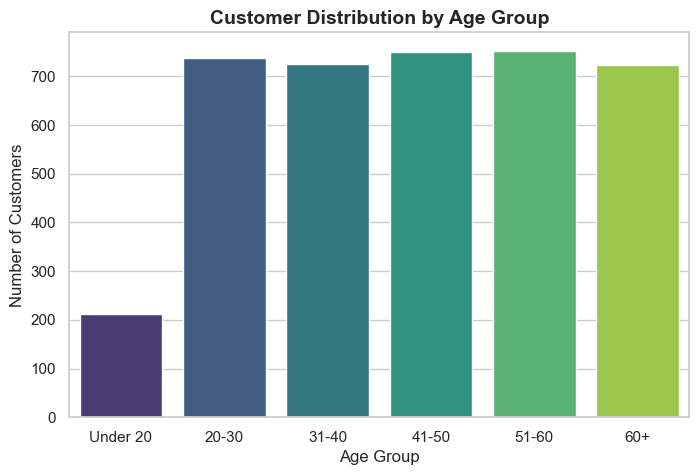

In [24]:
# Visualization

# Set the style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Create the bar plot
sns.countplot(data=df, x='Age_Group', hue='Age_Group', palette='viridis', legend=False)

# Add titles and labels
plt.title('Customer Distribution by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# Show the plot
plt.show()



This Bar Chart shows demographic breakdown and shows how i grouped those raw ages into actionable business segments.

Check Unique Values for categorical columns

In [16]:
df["Gender"].unique()

array(['Male', 'Female'], dtype=object)

In [17]:
df['Category'].unique()

array(['Clothing', 'Footwear', 'Outerwear', 'Accessories'], dtype=object)

In [18]:
df['Payment Method'].unique()

array(['Venmo', 'Cash', 'Credit Card', 'PayPal', 'Bank Transfer',
       'Debit Card'], dtype=object)

In [19]:
df['Frequency of Purchases'].unique()

array(['Fortnightly', 'Weekly', 'Annually', 'Quarterly', 'Bi-Weekly',
       'Monthly', 'Every 3 Months'], dtype=object)

In [20]:
df['Season'].unique()

array(['Winter', 'Spring', 'Summer', 'Fall'], dtype=object)

Exploratory Data Analysis(EDA)

 Analysis 1: Customer Age Distribution

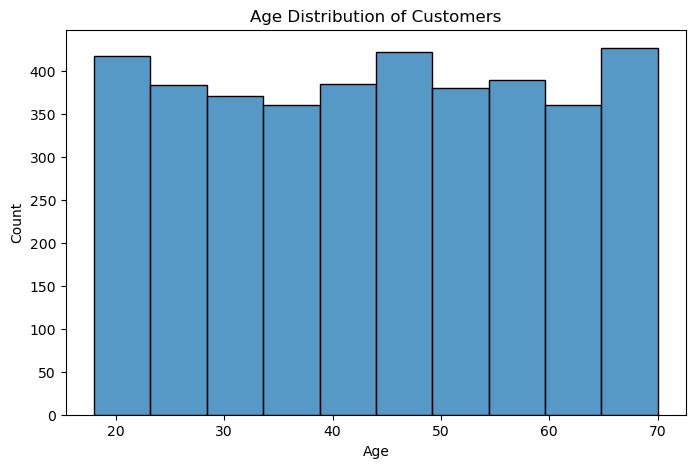

In [ ]:

plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=10)

plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Count')

plt.show()

Insight: Customer ages are relatively evenly distributed across adult age groups, indicating a diverse customer base.

Analysis 2 : Gender Distribution

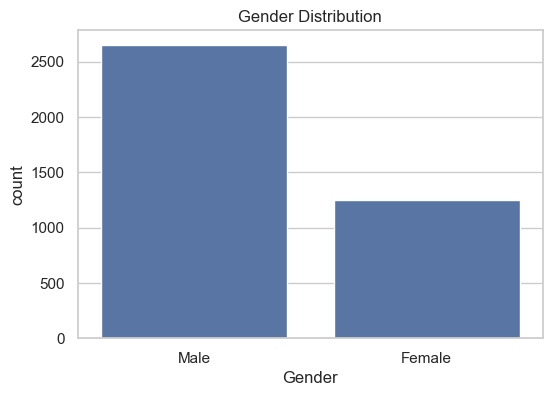

In [25]:
plt.figure(figsize=(6,4))

sns.countplot(x='Gender', data=df)

plt.title('Gender Distribution')

plt.show()

Insight : The customer base is almost evently split between male and female shoppers.


Analysis 3: Purchase Amount Distribution

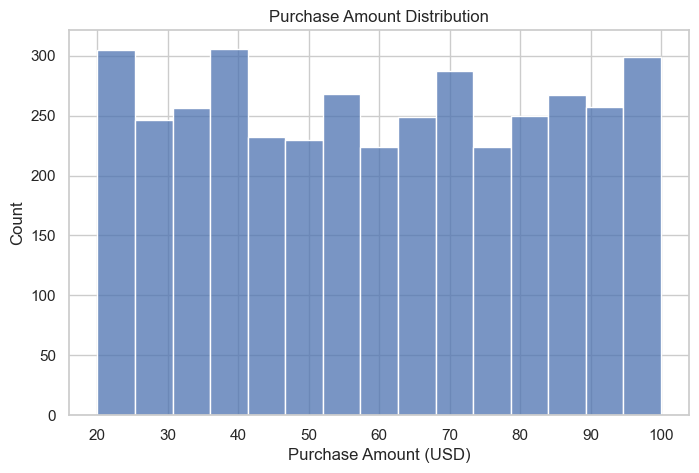

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Purchase Amount (USD)'],
    bins=15
)

plt.title('Purchase Amount Distribution')

plt.show()

Most purcahse amounts are concentrated within a moderate spending range, with fewer high-value purchases.

Analysis 4: Average Spending by Gender

In [27]:
gender_spending = df.groupby("Gender")["Purchase Amount (USD)"].mean()
print(gender_spending)

Gender
Female    60.249199
Male      59.536199
Name: Purchase Amount (USD), dtype: float64


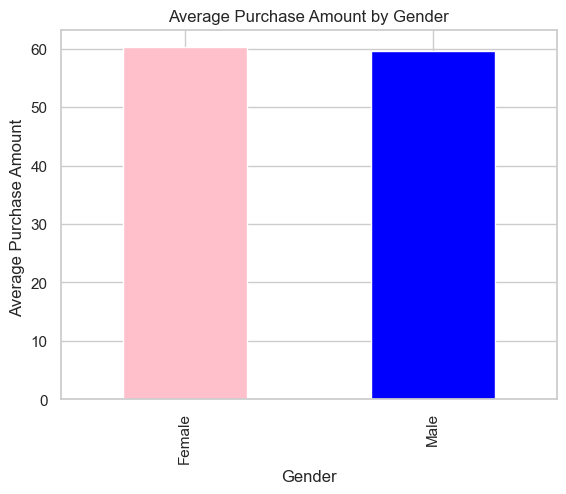

In [ ]:
# Visualization:(Which gender spends more on average?)

gender_spending.plot(kind='bar', color=['pink','blue'])
plt.title('Average Purchase Amount by Gender')
plt.ylabel("Average Purchase Amount ")
plt.show()

Analysis 5: Revenue by Category

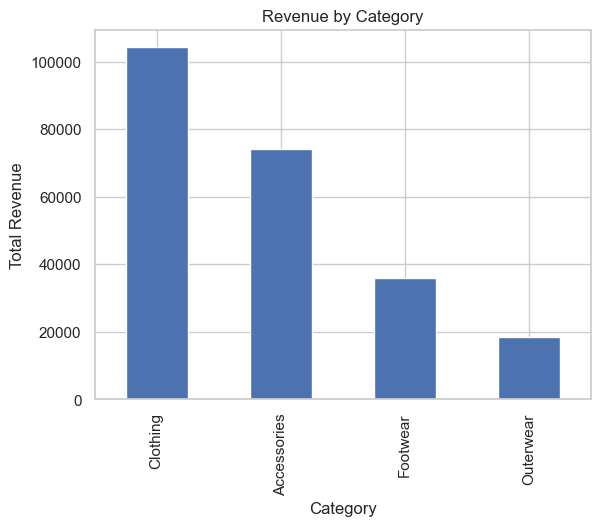

In [ ]:
# Which product categories contribute the most revenue?
category_sales = df.groupby(
    'Category'
)['Purchase Amount (USD)'].sum()

category_sales.sort_values(
    ascending=False
).plot(
    kind='bar'
)

plt.title('Revenue by Category')

plt.ylabel('Total Revenue')

plt.show()